In [ ]:
!pip install prophet

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 14.4 MB/s eta 0:00:00


#A. IMPORT LIBRARY

In [47]:
from prophet import Prophet
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import joblib
import holidays
import time
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#B. DATA UNDERSTANDING

1. Collect Initial Data

In [3]:
df = pd.read_excel('/content/drive/MyDrive/skripsi/prediksi pasien/raw_data.xlsx', header=None)

In [4]:
df.columns = [
    'no_register',
    'no_rekam_medis',
    'jenis_kelamin',
    'umur',
    'status_umur',
    'tgl_masuk',
    'tgl_keluar',
    'kd_penyakit',
    'nama_penyakit',
    'tb_ralan',
    'bb_ralan',
    'tb_ranap',
    'bb_ranap'
]

df.head()

,no_register,no_rekam_medis,jenis_kelamin,umur,status_umur,tgl_masuk,tgl_keluar,kd_penyakit,nama_penyakit,tb_ralan,bb_ralan,tb_ranap,bb_ranap
0,2023/01/01/000002,256521,P,61,Th,2023-01-01,2023-01-02,K30,Dyspepsia,tb,tb,tt,tb
1,2023/01/01/000003,266521,P,63,Th,2023-01-01,2023-01-04,U07.1,Emergency use of U07.1,NaN,NaN,NaN,NaN
2,2023/01/01/000004,276521,L,62,Th,2023-01-01,2023-01-06,A16.2,"Tuberculosis of lung, without mention of bacte...",NaN,NaN,NaN,NaN
3,2023/01/01/000005,774213,P,21,Th,2023-01-01,2023-01-03,M32.9,"Systemic lupus erythematosus, unspecified",NaN,NaN,NaN,NaN
4,2023/01/01/000006,286521,P,68,Th,2023-01-02,2023-01-04,I63.9,"Cerebral infarction, unspecified",NaN,NaN,NaN,NaN


2. Describe Data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29459 entries, 0 to 29458
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   no_register     29459 non-null  object        
 1   no_rekam_medis  29459 non-null  int64         
 2   jenis_kelamin   29459 non-null  object        
 3   umur            29459 non-null  int64         
 4   status_umur     29459 non-null  object        
 5   tgl_masuk       29459 non-null  datetime64[ns]
 6   tgl_keluar      29459 non-null  datetime64[ns]
 7   kd_penyakit     29456 non-null  object        
 8   nama_penyakit   29456 non-null  object        
 9   tb_ralan        14998 non-null  object        
 10  bb_ralan        15801 non-null  object        
 11  tb_ranap        11352 non-null  object        
 12  bb_ranap        12662 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(9)
memory usage: 2.9+ MB


3. Explore Data

In [7]:
df.describe()

,no_rekam_medis,umur,tgl_masuk,tgl_keluar
count,29459.000000,29459.000000,29459,29459
mean,499909.482196,47.595811,2024-08-25 14:25:53.209545472,2024-08-28 14:14:41.577786112
min,26.000000,0.000000,2023-01-01 00:00:00,2023-01-02 00:00:00
25%,249323.000000,31.000000,2023-12-06 00:00:00,2023-12-08 00:00:00
50%,499824.000000,51.000000,2024-08-25 00:00:00,2024-08-28 00:00:00
75%,751476.000000,64.000000,2025-06-01 00:00:00,2025-06-05 00:00:00
max,999921.000000,2019.000000,2026-04-01 00:00:00,2026-04-06 00:00:00
std,288883.041284,35.474310,NaN,NaN


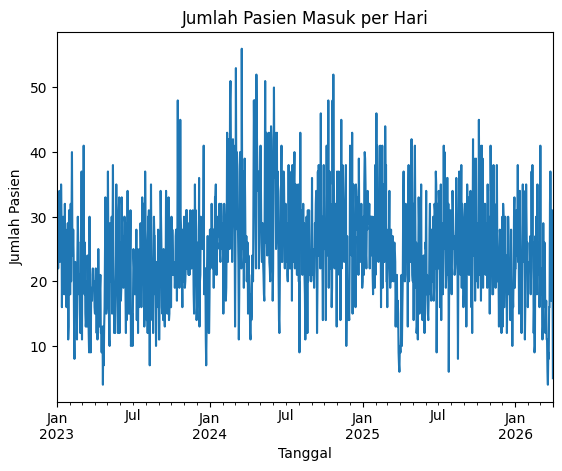

In [8]:
# Hitung jumlah pasien per hari
daily = df.groupby('tgl_masuk').size()

# Plot
plt.figure()
daily.plot()
plt.title('Jumlah Pasien Masuk per Hari')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Pasien')
plt.show()

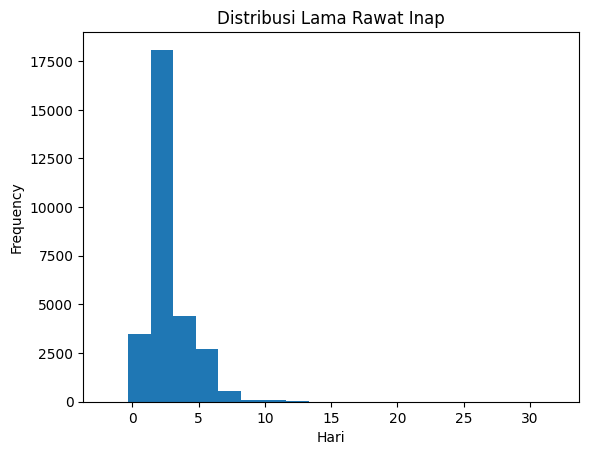

In [9]:
df['tgl_keluar'] = pd.to_datetime(df['tgl_keluar'])

df['lama_rawat'] = (df['tgl_keluar'] - df['tgl_masuk']).dt.days

df['lama_rawat'].plot(kind='hist', bins=20)
plt.title('Distribusi Lama Rawat Inap')
plt.xlabel('Hari')
plt.show()

4. Verify Data Quality

In [10]:
df.isnull().sum()

,0
no_register,0
no_rekam_medis,0
jenis_kelamin,0
umur,0
status_umur,0
tgl_masuk,0
tgl_keluar,0
kd_penyakit,3
nama_penyakit,3
tb_ralan,14461


#C. DATA PREPARATION

1. Select Data

In [11]:
df_selected = df[['no_register', 'tgl_masuk', 'tgl_keluar']].copy()

In [12]:
df_selected['tgl_masuk'] = pd.to_datetime(df_selected['tgl_masuk'])
df_selected['tgl_keluar'] = pd.to_datetime(df_selected['tgl_keluar'])

df_selected.head()

,no_register,tgl_masuk,tgl_keluar
0,2023/01/01/000002,2023-01-01,2023-01-02
1,2023/01/01/000003,2023-01-01,2023-01-04
2,2023/01/01/000004,2023-01-01,2023-01-06
3,2023/01/01/000005,2023-01-01,2023-01-03
4,2023/01/01/000006,2023-01-02,2023-01-04


2. Clean Data

In [13]:
df_selected.isnull().sum()

,0
no_register,0
tgl_masuk,0
tgl_keluar,0


In [14]:
df_selected.duplicated(subset=['no_register']).sum()

np.int64(484)

In [15]:
df_selected[
    df_selected.duplicated(keep=False)
].sort_values('no_register')

,no_register,tgl_masuk,tgl_keluar
14,2023/01/01/000023,2023-01-01,2023-01-03
15,2023/01/01/000023,2023-01-01,2023-01-03
22,2023/01/02/000231,2023-01-02,2023-01-06
23,2023/01/02/000231,2023-01-02,2023-01-06
26,2023/01/02/000306,2023-01-02,2023-01-06
...,...,...,...
29227,2026/03/22/000028,2026-03-22,2026-03-24
29248,2026/03/24/000034,2026-03-24,2026-03-27
29249,2026/03/24/000034,2026-03-24,2026-03-27
29446,2026/03/31/000672,2026-04-01,2026-04-03


In [16]:
df_selected = df_selected.drop_duplicates(subset=['no_register'])

In [18]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28975 entries, 0 to 29458
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_register  28975 non-null  object        
 1   tgl_masuk    28975 non-null  datetime64[ns]
 2   tgl_keluar   28975 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 905.5+ KB


In [19]:
df_selected[df_selected['tgl_keluar'] < df_selected['tgl_masuk']]\
.sort_values(by='tgl_masuk')

,no_register,tgl_masuk,tgl_keluar
1640,2023/03/14/000442,2023-03-14,2023-03-13
12426,2024/06/02/000056,2024-06-05,2024-06-03


In [20]:
df_selected = df_selected[df_selected['tgl_keluar'] >= df_selected['tgl_masuk']]

In [21]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28973 entries, 0 to 29458
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   no_register  28973 non-null  object        
 1   tgl_masuk    28973 non-null  datetime64[ns]
 2   tgl_keluar   28973 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 905.4+ KB


3. Construct Data

In [22]:
df_selected['tanggal'] = df_selected.apply(
    lambda row: pd.date_range(start=row['tgl_masuk'], end=row['tgl_keluar']),
    axis=1
)

df_exploded = df_selected.explode('tanggal')
daily = df_exploded.groupby('tanggal').size().reset_index(name='jumlah_pasien')

daily = daily.sort_values(by='tanggal').reset_index(drop=True)
daily.head(10)

,tanggal,jumlah_pasien
0,2023-01-01,13
1,2023-01-02,37
2,2023-01-03,62
3,2023-01-04,74
4,2023-01-05,86
5,2023-01-06,90
6,2023-01-07,85
7,2023-01-08,78
8,2023-01-09,103
9,2023-01-10,93


In [23]:
daily['is_weekend'] = daily['tanggal'].dt.weekday.isin([5,6]).astype(int)

In [24]:
daily[['tanggal','is_weekend']].head(10)

,tanggal,is_weekend
0,2023-01-01,1
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
5,2023-01-06,0
6,2023-01-07,1
7,2023-01-08,1
8,2023-01-09,0
9,2023-01-10,0


In [25]:
years = range(2023, 2027)

indo_holidays = holidays.Indonesia(years=years)

In [26]:
holiday_df = pd.DataFrame(
    list(indo_holidays.items()),
    columns=['tanggal', 'nama_libur']
)

holiday_df.head(20)

,tanggal,nama_libur
0,2024-01-01,New Year's Day
1,2024-08-17,Independence Day
2,2024-12-25,Christmas Day
3,2024-04-10,Eid al-Fitr
4,2024-04-11,Eid al-Fitr Second Day
5,2024-06-17,Eid al-Adha
6,2024-02-08,Isra' and Mi'raj
7,2024-05-09,Ascension Day
8,2024-07-07,Islamic New Year
9,2024-09-16,Prophet's Birthday


In [27]:
def get_holiday_dates(keyword):
    return holiday_df[
        holiday_df['nama_libur'].str.contains(keyword, case=False, na=False)
    ]['tanggal'].tolist()

In [28]:
# Tahun Baru Imlek
imlek_dates = get_holiday_dates("Lunar New Year")

# Idul Fitri Hari Pertama
idul_fitri_dates = get_holiday_dates("^Eid al-Fitr$")

# Idul Fitri Hari Kedua
idul_fitri_sec_dates = get_holiday_dates("Eid al-Fitr Second Day")

# Idul Adha
idul_adha_dates = get_holiday_dates("Eid al-Adha")

# Hari Raya Waisak
waisak_dates = get_holiday_dates("Vesak")

# Hari Raya Natal
natal_dates = get_holiday_dates("Christmas")

# Hari Raya Nyepi
nyepi_dates = get_holiday_dates("Day of Silence")

In [29]:
daily['tanggal'] = pd.to_datetime(daily['tanggal'])

def add_event_range(df, event_dates, column_name,
                    days_before=7,
                    days_after=7):

    df[column_name] = 0

    for date in pd.to_datetime(event_dates):

        start = date - pd.Timedelta(days=days_before)
        end = date + pd.Timedelta(days=days_after)

        df.loc[
            (df['tanggal'] >= start) &
            (df['tanggal'] <= end),
            column_name
        ] = 1

    return df

In [30]:
daily = add_event_range(daily, imlek_dates, 'is_imlek')
daily = add_event_range(daily, idul_fitri_dates, 'is_idulfitri')
daily = add_event_range(daily, idul_fitri_sec_dates, 'is_idulfitri_sec')
daily = add_event_range(daily, idul_adha_dates, 'is_iduladha')
daily = add_event_range(daily, waisak_dates, 'is_waisak')
daily = add_event_range(daily, natal_dates, 'is_natal')
daily = add_event_range(daily, nyepi_dates, 'is_nyepi')

In [31]:
daily[['tanggal','is_imlek', 'is_idulfitri', 'is_idulfitri_sec', 'is_iduladha', 'is_waisak', 'is_waisak', 'is_waisak', 'is_nyepi']].head(50)

,tanggal,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_waisak,is_waisak,is_nyepi
0,2023-01-01,0,0,0,0,0,0,0,0
1,2023-01-02,0,0,0,0,0,0,0,0
2,2023-01-03,0,0,0,0,0,0,0,0
3,2023-01-04,0,0,0,0,0,0,0,0
4,2023-01-05,0,0,0,0,0,0,0,0
5,2023-01-06,0,0,0,0,0,0,0,0
6,2023-01-07,0,0,0,0,0,0,0,0
7,2023-01-08,0,0,0,0,0,0,0,0
8,2023-01-09,0,0,0,0,0,0,0,0
9,2023-01-10,0,0,0,0,0,0,0,0


In [32]:
daily['is_libur_nasional'] = daily['tanggal'].isin(indo_holidays).astype(int)

/tmp/ipykernel_460/1191417220.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  daily['is_libur_nasional'] = daily['tanggal'].isin(indo_holidays).astype(int)


In [33]:
daily[['tanggal','is_libur_nasional']].head(10)

,tanggal,is_libur_nasional
0,2023-01-01,1
1,2023-01-02,0
2,2023-01-03,0
3,2023-01-04,0
4,2023-01-05,0
5,2023-01-06,0
6,2023-01-07,0
7,2023-01-08,0
8,2023-01-09,0
9,2023-01-10,0


In [34]:
daily['lag_1'] = daily['jumlah_pasien'].shift(1)
daily['lag_7'] = daily['jumlah_pasien'].shift(7)
daily['lag_14'] = daily['jumlah_pasien'].shift(14)
daily['lag_21'] = daily['jumlah_pasien'].shift(21)
daily['lag_30'] = daily['jumlah_pasien'].shift(30)

daily = daily.dropna().reset_index(drop=True)

lag_columns = ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_30']
daily[lag_columns] = daily[lag_columns].astype('int64')

Deteksi dan Hapus Outlier

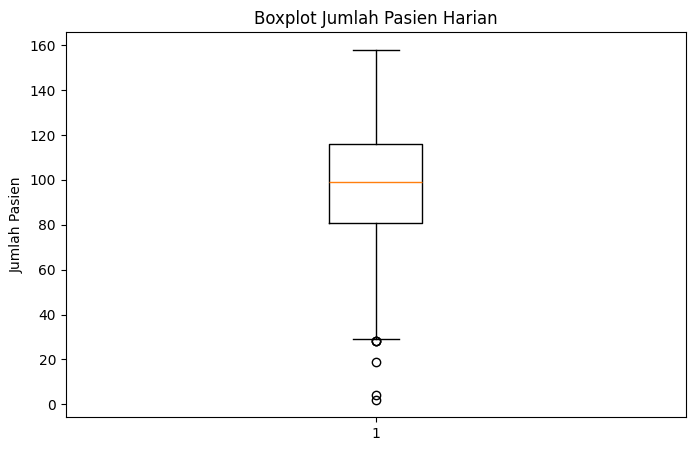

In [35]:
# Membuat boxplot
plt.figure(figsize=(8,5))

plt.boxplot(daily['jumlah_pasien'])

# Judul dan label
plt.title('Boxplot Jumlah Pasien Harian')
plt.ylabel('Jumlah Pasien')

# Tampilkan
plt.show()

In [36]:
Q1 = daily['jumlah_pasien'].quantile(0.25)
Q3 = daily['jumlah_pasien'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = daily[
    (daily['jumlah_pasien'] < lower_bound) |
    (daily['jumlah_pasien'] > upper_bound)
]

outlier

,tanggal,jumlah_pasien,is_weekend,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_natal,is_nyepi,is_libur_nasional,lag_1,lag_7,lag_14,lag_21,lag_30
789,2025-03-30,28,1,0,1,1,0,0,0,1,0,44,75,96,94,119
790,2025-03-31,28,0,0,1,1,0,0,0,1,1,28,77,101,111,105
1146,2026-03-22,28,1,0,1,1,0,0,0,1,1,29,88,68,87,85
1159,2026-04-04,19,1,0,0,0,0,0,0,0,0,30,123,29,86,92
1160,2026-04-05,4,1,0,0,0,0,0,0,0,1,19,119,28,88,82
1161,2026-04-06,2,0,0,0,0,0,0,0,0,0,4,127,36,78,76


In [37]:
daily = daily[
    (daily['jumlah_pasien'] >= lower_bound) &
    (daily['jumlah_pasien'] <= upper_bound)
].copy()

print("Jumlah data setelah menghapus outlier:", len(daily))

Jumlah data setelah menghapus outlier: 1156


4. Integrate Data

In [38]:
print(daily.shape)
daily.head()

(1156, 16)


,tanggal,jumlah_pasien,is_weekend,is_imlek,is_idulfitri,is_idulfitri_sec,is_iduladha,is_waisak,is_natal,is_nyepi,is_libur_nasional,lag_1,lag_7,lag_14,lag_21,lag_30
0,2023-01-31,70,0,0,0,0,0,0,0,0,0,69,91,94,93,13
1,2023-02-01,77,0,0,0,0,0,0,0,0,0,70,69,89,98,37
2,2023-02-02,69,0,0,0,0,0,0,0,0,0,77,68,79,91,62
3,2023-02-03,78,0,0,0,0,0,0,0,0,0,69,71,84,82,74
4,2023-02-04,79,1,0,0,0,0,0,0,0,0,78,57,80,77,86


In [39]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1156 entries, 0 to 1158
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tanggal            1156 non-null   datetime64[ns]
 1   jumlah_pasien      1156 non-null   int64         
 2   is_weekend         1156 non-null   int64         
 3   is_imlek           1156 non-null   int64         
 4   is_idulfitri       1156 non-null   int64         
 5   is_idulfitri_sec   1156 non-null   int64         
 6   is_iduladha        1156 non-null   int64         
 7   is_waisak          1156 non-null   int64         
 8   is_natal           1156 non-null   int64         
 9   is_nyepi           1156 non-null   int64         
 10  is_libur_nasional  1156 non-null   int64         
 11  lag_1              1156 non-null   int64         
 12  lag_7              1156 non-null   int64         
 13  lag_14             1156 non-null   int64         
 14  lag_21       

5. Format Data

In [40]:
df = pd.read_csv('/content/drive/MyDrive/skripsi/prediksi pasien/data_min_30_2.csv')

1. Input dan Output

In [41]:
df_prophet = df.copy()

In [42]:
df_prophet = df_prophet.rename(columns={
    'tanggal':'ds',
    'jumlah_pasien':'y'
})

regressors = [
    'is_weekend',
    'is_libur_nasional',
    'is_imlek',
    'is_idulfitri',
    'is_idulfitri_sec',
    'is_iduladha',
    'is_waisak',
    'is_natal',
    'is_nyepi'
]

df_prophet = df_prophet[
    ['ds','y'] + regressors
]

df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

Split Dataset 70:30

In [44]:
train_size = int(len(df_prophet) * 0.7)

train = df_prophet.iloc[:train_size].copy()
test = df_prophet.iloc[train_size:].copy()

In [45]:
print("train :", train.shape)
print("test  :", test.shape)

print(
    "Train:",
    train.index.min(),
    "sampai",
    train.index.max()
)

print(
    "Test:",
    test.index.min(),
    "sampai",
    test.index.max()
)

train : (809, 11)
test  : (347, 11)
Train: 0 sampai 808
Test: 809 sampai 1155


In [48]:
MODEL_PATH = "/content/drive/MyDrive/skripsi/prediksi pasien/data_save_preparation/prophet"

os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(train, f"{MODEL_PATH}/train.pkl")
joblib.dump(test, f"{MODEL_PATH}/test.pkl")

['/content/drive/MyDrive/skripsi/prediksi pasien/data_save_preparation/prophet/test.pkl']

#D. MODELING

1. Hyperparameter Tuning With Optuna

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
def objective(trial):

    monthly_fourier = trial.suggest_int(
        "monthly_fourier",
        3,
        10
    )

    params = {

        "changepoint_prior_scale":
            trial.suggest_float(
                "changepoint_prior_scale",
                0.01,
                0.3,
                log=True
            ),

        "changepoint_range":
            trial.suggest_float(
              "changepoint_range",
              0.8,
              0.95
            ),

        "seasonality_prior_scale":
            trial.suggest_float(
                "seasonality_prior_scale",
                0.01,
                0.1,
                log=True
            ),

         "holidays_prior_scale":
            trial.suggest_float(
              "holidays_prior_scale",
              0.01,
              0.1,
              log=True
            ),

        "seasonality_mode":
            trial.suggest_categorical(
                "seasonality_mode",
                ["additive","multiplicative"]
            ),

        "yearly_seasonality":
            trial.suggest_categorical(
                "yearly_seasonality",
                [True,False]
            ),

        "weekly_seasonality":
            trial.suggest_categorical(
                "weekly_seasonality",
                [True,False]
            ),

        "daily_seasonality":False

    }

    mae_scores = []
    rmse_scores = []
    mape_scores = []
    wape_scores = []

    for train_idx, val_idx in tscv.split(train):

        train_fold = train.iloc[train_idx]

        val_fold = train.iloc[val_idx]

        model = Prophet(**params)

        model.add_seasonality(
            name="monthly",
            period=30.5,
            fourier_order=monthly_fourier
        )

        # tambahkan semua regressor
        for reg in regressors:
            model.add_regressor(reg)

        model.fit(train_fold)

        forecast = model.predict(
            val_fold[['ds'] + regressors]
        )

        y_true = val_fold["y"].values
        y_pred = forecast["yhat"].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
        wape = (
            np.sum(
                np.abs(y_true - y_pred)
            )
            /
            np.sum(
                np.abs(y_true)
            )
        ) * 100

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        mape_scores.append(mape)
        wape_scores.append(wape)

    # Rata-rata seluruh fold
    mean_mae = np.mean(mae_scores)
    mean_rmse = np.mean(rmse_scores)
    mean_mape = np.mean(mape_scores)
    mean_wape = np.mean(wape_scores)

    # Simpan sebagai user attribute
    trial.set_user_attr("rmse", mean_rmse)
    trial.set_user_attr("mape", mean_mape)
    trial.set_user_attr("wape", mean_wape)

    return mean_mae

In [ ]:
study = optuna.create_study(direction="minimize")

start_time = time.time()

study.optimize(
    objective,
    n_trials=100
)

end_time = time.time()

optuna_time = end_time - start_time

print(f"Total waktu Optuna: {optuna_time:.2f} detik")
print(f"Total waktu Optuna: {optuna_time/60:.2f} menit")

[I 2026-08-15 10:53:48,722] A new study created in memory with name: no-name-ddd6e819-4055-4403-94b2-78b960fd0343
[I 2026-08-15 10:53:49,905] Trial 0 finished with value: 21.047712447870232 and parameters: {'monthly_fourier': 10, 'changepoint_prior_scale': 0.1844763098546279, 'changepoint_range': 0.8688458846730531, 'seasonality_prior_scale': 0.01566648066310126, 'holidays_prior_scale': 0.04098796243874785, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': True, 'weekly_seasonality': False}. Best is trial 0 with value: 21.047712447870232.
[I 2026-08-15 10:53:51,147] Trial 1 finished with value: 17.172005040513127 and parameters: {'monthly_fourier': 6, 'changepoint_prior_scale': 0.016373584915789757, 'changepoint_range': 0.8595808906574103, 'seasonality_prior_scale': 0.07229063336032072, 'holidays_prior_scale': 0.04205489863345832, 'seasonality_mode': 'multiplicative', 'yearly_seasonality': False, 'weekly_seasonality': False}. Best is trial 1 with value: 17.172005040513127.
[I

Total waktu Optuna: 170.84 detik
Total waktu Optuna: 2.85 menit


In [ ]:
best_trial = study.best_trial
print(study.best_params)
print("Best Trial :", best_trial.number)
print("MAE  :", best_trial.value)
print("RMSE :", best_trial.user_attrs["rmse"])
print("MAPE :", best_trial.user_attrs["mape"])
print("WAPE :", best_trial.user_attrs["wape"])

{'monthly_fourier': 7, 'changepoint_prior_scale': 0.08224103702596837, 'changepoint_range': 0.8822676603805658, 'seasonality_prior_scale': 0.029671483925535293, 'holidays_prior_scale': 0.029712774326412006, 'seasonality_mode': 'additive', 'yearly_seasonality': True, 'weekly_seasonality': True}
Best Trial : 24
MAE  : 14.68350751532071
RMSE : 18.27972138646125
MAPE : 15.830823495206861
WAPE : 14.497726205341303


In [ ]:
best_params = study.best_params.copy()

monthly_fourier = best_params.pop("monthly_fourier")

2. Training Best Hyperparameter With Time Series Split

In [ ]:
train_mae_scores = []
train_rmse_scores = []
train_mape_scores = []
train_wape_scores = []

val_mae_scores = []
val_rmse_scores = []
val_mape_scores = []
val_wape_scores = []

training_times = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(train), start=1):

    train_fold = train.iloc[train_idx]
    val_fold = train.iloc[val_idx]

    model = Prophet(
        **best_params,
        daily_seasonality=False
    )

    model.add_seasonality(
        name="monthly",
        period=30.5,
        fourier_order=monthly_fourier
    )

    for reg in regressors:
        model.add_regressor(reg)

    start = time.time()

    model.fit(train_fold)

    end = time.time()

    elapsed = end - start

    training_times.append(elapsed)

    print(f"Fold {fold} : {elapsed:.2f} detik")

    # ==========================
    # Prediksi Training Fold
    # ==========================

    train_forecast = model.predict(
        train_fold[['ds'] + regressors]
    )

    train_y_true = train_fold["y"].values
    train_y_pred = train_forecast["yhat"].values

    train_mae = mean_absolute_error(train_y_true, train_y_pred)
    train_rmse = np.sqrt(mean_squared_error(train_y_true, train_y_pred))
    train_mape = mean_absolute_percentage_error(train_y_true, train_y_pred) * 100
    train_wape = (
            np.sum(
                np.abs(train_y_true - train_y_pred)
            )
            /
            np.sum(
                np.abs(train_y_true)
            )
        ) * 100

    # ==========================
    # Prediksi Validation Fold
    # ==========================

    val_forecast = model.predict(
        val_fold[['ds'] + regressors]
    )

    val_y_true = val_fold["y"].values
    val_y_pred = val_forecast["yhat"].values

    val_mae = mean_absolute_error(val_y_true, val_y_pred)
    val_rmse = np.sqrt(mean_squared_error(val_y_true, val_y_pred))
    val_mape = mean_absolute_percentage_error(val_y_true, val_y_pred) * 100
    val_wape = (
            np.sum(
                np.abs(val_y_true - val_y_pred)
            )
            /
            np.sum(
                np.abs(val_y_true)
            )
        ) * 100

    train_mae_scores.append(train_mae)
    train_rmse_scores.append(train_rmse)
    train_mape_scores.append(train_mape)
    train_wape_scores.append(train_wape)

    val_mae_scores.append(val_mae)
    val_rmse_scores.append(val_rmse)
    val_mape_scores.append(val_mape)
    val_wape_scores.append(val_wape)

    print(
        f"Fold {fold}"
        f"\n  Train      -> MAE: {train_mae:.4f}"
        f" | RMSE: {train_rmse:.4f}"
        f" | MAPE: {train_mape:.2f}%"
        f" | WAPE: {train_wape:.2f}%"
        f"\n  Validation -> MAE: {val_mae:.4f}"
        f" | RMSE: {val_rmse:.4f}"
        f" | MAPE: {val_mape:.2f}%\n"
        f"  | WAPE: {val_wape:.2f}%"
    )

print("=" * 60)
print("Average Training Metrics")
print(f"MAE  : {np.mean(train_mae_scores):.4f}")
print(f"RMSE : {np.mean(train_rmse_scores):.4f}")
print(f"MAPE : {np.mean(train_mape_scores):.2f}%")
print(f"WAPE : {np.mean(train_wape_scores):.2f}%\n")

print("\nAverage Validation Metrics")
print(f"MAE  : {np.mean(val_mae_scores):.4f}")
print(f"RMSE : {np.mean(val_rmse_scores):.4f}")
print(f"MAPE : {np.mean(val_mape_scores):.2f}%")
print(f"WAPE : {np.mean(val_wape_scores):.2f}%\n")

print(f"\nRata-rata waktu training : {np.mean(training_times):.2f} detik")

Fold 1 : 0.08 detik
Fold 1
  Train      -> MAE: 6.4316 | RMSE: 8.0068 | MAPE: 9.50% | WAPE: 9.07%
  Validation -> MAE: 9.3421 | RMSE: 12.3661 | MAPE: 12.05%
  | WAPE: 12.05%
Fold 2 : 0.08 detik
Fold 2
  Train      -> MAE: 6.0486 | RMSE: 7.6905 | MAPE: 8.64% | WAPE: 8.15%
  Validation -> MAE: 13.9353 | RMSE: 17.5425 | MAPE: 15.13%
  | WAPE: 14.47%
Fold 3 : 0.12 detik
Fold 3
  Train      -> MAE: 6.9881 | RMSE: 9.1551 | MAPE: 9.12% | WAPE: 8.58%
  Validation -> MAE: 15.6555 | RMSE: 20.4243 | MAPE: 15.76%
  | WAPE: 13.93%
Fold 4 : 0.17 detik
Fold 4
  Train      -> MAE: 8.3949 | RMSE: 11.0687 | MAPE: 10.24% | WAPE: 9.42%
  Validation -> MAE: 17.4910 | RMSE: 21.3990 | MAPE: 18.70%
  | WAPE: 16.52%
Fold 5 : 0.19 detik
Fold 5
  Train      -> MAE: 9.0112 | RMSE: 11.6383 | MAPE: 10.56% | WAPE: 9.75%
  Validation -> MAE: 16.9937 | RMSE: 19.6668 | MAPE: 17.52%
  | WAPE: 15.51%
Average Training Metrics
MAE  : 7.3749
RMSE : 9.5119
MAPE : 9.61%
WAPE : 8.99%


Average Validation Metrics
MAE  : 14.6835

3. Final Training

In [ ]:
final_model = Prophet(
    **best_params,
    daily_seasonality=False
)

final_model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=monthly_fourier
)

for reg in regressors:
    final_model.add_regressor(reg)

start_time = time.time()

final_model.fit(train)

end_time = time.time()

running_time = end_time - start_time

print(f"Running time: {running_time:.2f} detik")

Running time: 0.23 detik


4. Prediction With Data Test

In [ ]:
start = time.time()

forecast = model.predict(
    test[['ds'] + regressors]
)

end = time.time()

print(f"Waktu prediksi: {end - start:.4f} detik")

Waktu prediksi: 0.1580 detik


In [ ]:
hasil = test.copy()

hasil["Prediksi"] = forecast["yhat"].values
hasil["yhat_lower"] = forecast["yhat_lower"].values
hasil["yhat_upper"] = forecast["yhat_upper"].values

5. Asses Model

In [ ]:
mae = mean_absolute_error(
    hasil['y'],
    hasil['Prediksi']
)

rmse = np.sqrt(
    mean_squared_error(
        hasil['y'],
        hasil['Prediksi']
    )
)

mape = np.mean(
    np.abs(
        (hasil['y']-hasil['Prediksi'])/
        hasil['y']
    )
)*100

wape = (
        np.sum(
            np.abs(hasil['y'] - hasil['Prediksi'])
        )
        /
        np.sum(
            np.abs(hasil['y'])
        )
    ) * 100

print("MAE :",mae)
print("RMSE:",rmse)
print("MAPE:",mape)
print("WAPE:",wape)

MAE : 15.875402837681124
RMSE: 20.44250440756987
MAPE: 17.853268090103843
WAPE: 15.178169352166613


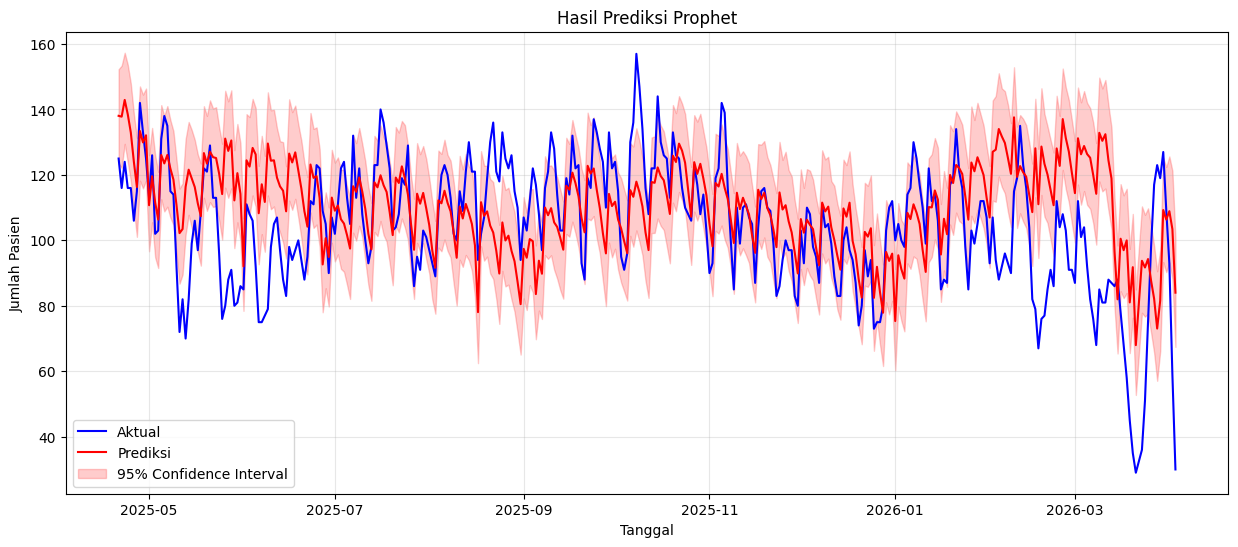

In [ ]:
plt.figure(figsize=(15,6))

# Data aktual
plt.plot(
    hasil["ds"],
    hasil["y"],
    label="Aktual",
    color="blue"
)

# Prediksi
plt.plot(
    hasil["ds"],
    hasil["Prediksi"],   # atau hasil["yhat"]
    label="Prediksi",
    color="red"
)

# Interval prediksi
plt.fill_between(
    hasil["ds"],
    hasil["yhat_lower"],
    hasil["yhat_upper"],
    color="red",
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.xlabel("Tanggal")
plt.ylabel("Jumlah Pasien")
plt.title("Hasil Prediksi Prophet")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#E. SAVE MODEL

In [ ]:
from prophet.serialize import model_to_json

MODEL_PATH = "/content/drive/MyDrive/skripsi/prediksi pasien/model"

os.makedirs(MODEL_PATH, exist_ok=True)

In [ ]:
with open(f"{MODEL_PATH}/prophet_model.json", "w") as fout:
    fout.write(model_to_json(final_model))

In [ ]:
regressors = [
    "is_weekend",
    "is_libur_nasional",
    "is_imlek",
    "is_idulfitri",
    "is_idulfitri_sec",
    "is_iduladha",
    "is_waisak",
    "is_natal",
    "is_nyepi"
]

In [ ]:
with open(f"{MODEL_PATH}/prophet_regressors.json", "w") as f:
    json.dump(regressors, f)